In [7]:
#Libraries Used
import os
import shutil
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:

source_dir = r"dog_image_dataset"  # Original dataset
output_dir = r"dog_image_dataset_raw"  # New dataset with train/val
# Split ratio
train_ratio = 0.8  # 80% train, 20% val

# Define train and val directories
train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")

# Create directories
for split in ["train", "val"]:
    for category in ["angry", "happy", "relaxed", "sad"]:
        os.makedirs(os.path.join(output_dir, split, category), exist_ok=True)

# Split images into train/val
for category in ["angry", "happy", "relaxed", "sad"]:
    category_path = os.path.join(source_dir, category)
    images = os.listdir(category_path)
    random.shuffle(images)  # Shuffle images
    
    split_idx = int(len(images) * train_ratio)  # Get train size

    # Move images to train and val folders
    for i, img_name in enumerate(images):
        src_path = os.path.join(category_path, img_name)
        
        if i < split_idx:
            dst_path = os.path.join(train_dir, category, img_name)  # Train folder
        else:
            dst_path = os.path.join(val_dir, category, img_name)  # Val folder
        
        shutil.copy(src_path, dst_path)  # Copy image

print("✅ Dataset successfully split into train and val!")


✅ Dataset successfully split into train and val!


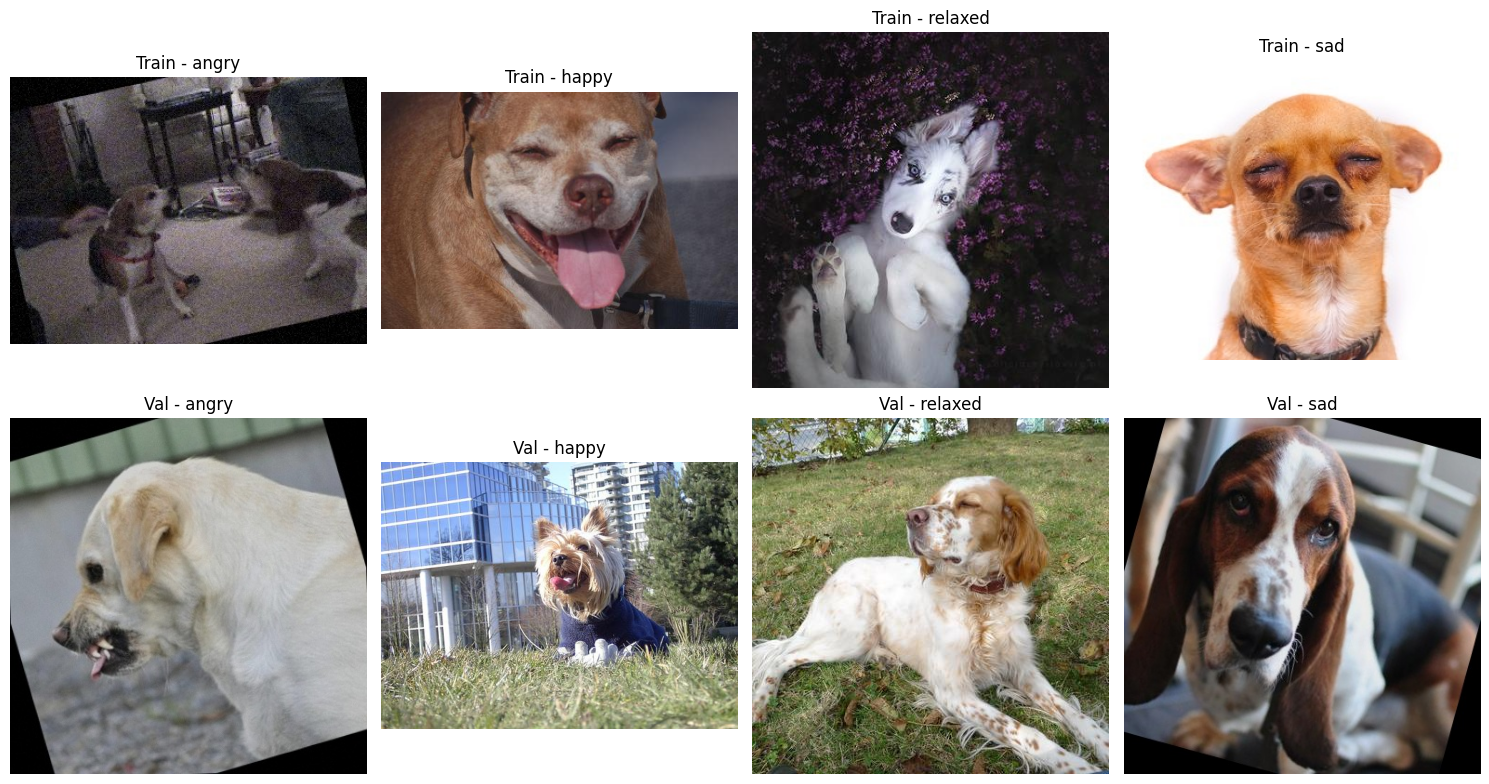

In [5]:
base_dir = r"dog_image_dataset_raw"
emotions = ["angry", "happy", "relaxed", "sad"]  # Grouped by emotion
# Set up 2 rows (train & val) and 4 columns (emotions)
fig, ax = plt.subplots(2, len(emotions), figsize=(15, 8))
for i, emotion in enumerate(emotions):
    for j, dataset in enumerate(["train", "val"]):  # train (row 0), val (row 1)
        folder_path = os.path.join(base_dir, dataset, emotion)

        # Ensure folder exists and is not empty
        if os.path.exists(folder_path) and os.listdir(folder_path):
            img_name = random.choice(os.listdir(folder_path))  # Random image
            img_path = os.path.join(folder_path, img_name)

            img = cv2.imread(img_path)  # Read image
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

            ax[j, i].imshow(img)
            ax[j, i].set_title(f"{dataset.capitalize()} - {emotion}")
            ax[j, i].axis("off")
        else:
            ax[j, i].set_title(f"{dataset.capitalize()} - {emotion} (No Images)")
            ax[j, i].axis("off")

plt.tight_layout()
plt.show()


In [6]:
# Paths for processed dataset
output_base_dir = r"dog_image_dataset_raw"
train_output_dir = os.path.join(output_base_dir, "train")
val_output_dir = os.path.join(output_base_dir, "val")
# Function to count images in each category folder
def count_images(split_dir):
    category_counts = {}
    for category in os.listdir(split_dir):
        category_path = os.path.join(split_dir, category)
        if os.path.isdir(category_path):  # Ensure it's a folder
            num_images = len(os.listdir(category_path))
            category_counts[category] = num_images
    return category_counts

# Count images in train and val folders
train_counts = count_images(train_output_dir)
val_counts = count_images(val_output_dir)

# Display counts
print("📂 **Train Set Image Counts**")
for category, count in train_counts.items():
    print(f"  - {category}: {count} images")

print("\n📂 **Validation Set Image Counts**")
for category, count in val_counts.items():
    print(f"  - {category}: {count} images")

📂 **Train Set Image Counts**
  - angry: 800 images
  - happy: 800 images
  - relaxed: 800 images
  - sad: 800 images

📂 **Validation Set Image Counts**
  - angry: 200 images
  - happy: 200 images
  - relaxed: 200 images
  - sad: 200 images


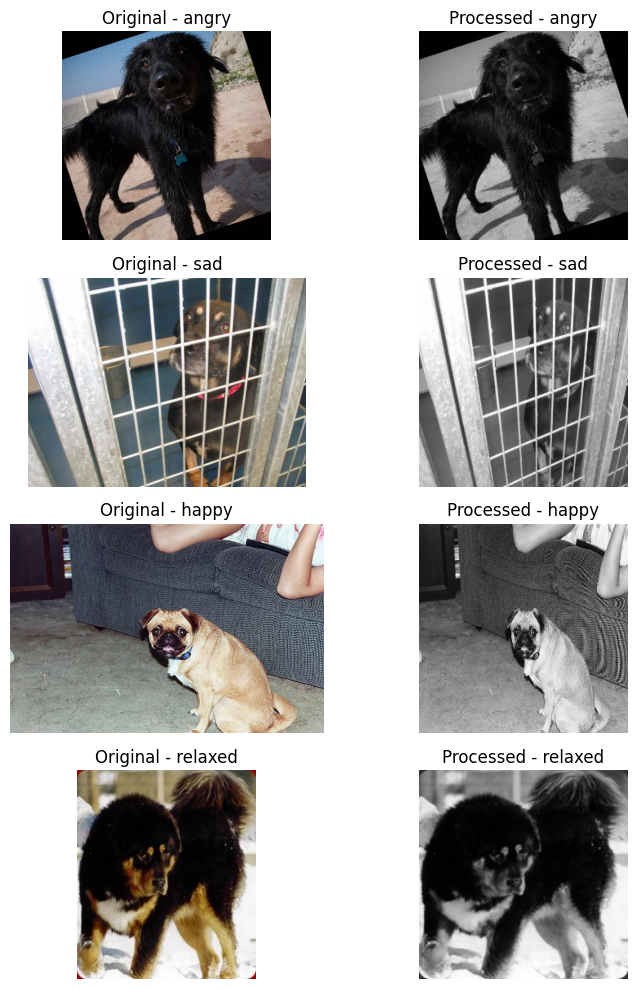

In [8]:
def preprocess_images(input_folder, output_folder, img_size=(256, 256)):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for split in ['train', 'val']:
        split_input_path = os.path.join(input_folder, split)
        split_output_path = os.path.join(output_folder, split)
        
        if not os.path.exists(split_output_path):
            os.makedirs(split_output_path)
        
        for emotion in ['angry', 'sad', 'happy', 'relaxed']:
            emotion_input_path = os.path.join(split_input_path, emotion)
            emotion_output_path = os.path.join(split_output_path, emotion)
            
            if not os.path.exists(emotion_output_path):
                os.makedirs(emotion_output_path)
            
            for img_name in os.listdir(emotion_input_path):
                img_path = os.path.join(emotion_input_path, img_name)
                
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
                img = cv2.resize(img, img_size)  # Resize image
                
                cv2.imwrite(os.path.join(emotion_output_path, img_name), img)  # Save processed image

def show_random_comparisons(original_folder, processed_folder):
    fig, axes = plt.subplots(4, 2, figsize=(8, 10))
    
    for i, emotion in enumerate(['angry', 'sad', 'happy', 'relaxed']):
        original_path = os.path.join(original_folder, 'train', emotion)
        processed_path = os.path.join(processed_folder, 'train', emotion)
        
        img_name = random.choice(os.listdir(original_path))
        original_img = cv2.imread(os.path.join(original_path, img_name))
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
        
        processed_img = cv2.imread(os.path.join(processed_path, img_name))
        
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f'Original - {emotion}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(processed_img)
        axes[i, 1].set_title(f'Processed - {emotion}')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Define paths
input_folder = r'dog_image_dataset_raw'
output_folder = r'dog_image_dataset_preprocessed' 

# Run preprocessing
preprocess_images(input_folder, output_folder)

# Show comparisons
show_random_comparisons(input_folder, output_folder)

In [9]:
# Paths for processed dataset
output_base_dir = r"dog_image_dataset_preprocessed"
train_output_dir = os.path.join(output_base_dir, "train")
val_output_dir = os.path.join(output_base_dir, "val")

# Function to count images in each category folder
def count_images(split_dir):
    category_counts = {}
    for category in os.listdir(split_dir):
        category_path = os.path.join(split_dir, category)
        if os.path.isdir(category_path):  # Ensure it's a folder
            num_images = len(os.listdir(category_path))
            category_counts[category] = num_images
    return category_counts

# Count images in train and val folders
train_counts = count_images(train_output_dir)
val_counts = count_images(val_output_dir)

# Display counts
print("📂 **Train Set Image Counts**")
for category, count in train_counts.items():
    print(f"  - {category}: {count} images")

print("\n📂 **Validation Set Image Counts**")
for category, count in val_counts.items():
    print(f"  - {category}: {count} images")


📂 **Train Set Image Counts**
  - angry: 800 images
  - happy: 800 images
  - relaxed: 800 images
  - sad: 800 images

📂 **Validation Set Image Counts**
  - angry: 200 images
  - happy: 200 images
  - relaxed: 200 images
  - sad: 200 images
